In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [121]:
df = pd.read_csv('train.csv')

In [122]:
trace_price_area = go.Scatter(
    x=df['GrLivArea'],
    y=df['SalePrice'],
    mode='markers',
    name='Дома',
    marker=dict(color='green', size=5, opacity=0.6),
    text=df.index,
    hovertemplate='Площадь: %{x} кв.фт<br>Цена: $%{y:}<extra></extra>'
)
layout_price_area = dict(
    title='Зависимость цены от жилой площади',
    xaxis=dict(title='Жилая площадь', ticklen=5, zeroline=False),
    yaxis=dict(title='Цена'),
    hovermode='closest'
)
fig = go.Figure(data=[trace_price_area], layout=layout_price_area)
fig.show()

In [123]:
top_neigh = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).head(10)
fig = {
    "data": [{
        "values": top_neigh.values,
        "labels": top_neigh.index,
        "name": "Районы",
        "hoverinfo": "label+percent+value",
        "hole": 0.3,
        "type": "pie"
    }],
    "layout": {
        "title": "Топ-10 самых дорогих районов",
        "annotations": [{
            "font": {"size": 16},
            "showarrow": True,
            "text": "Доля в общем объёме цен",
            "x": 0.5,
            "y": 1.05
        }]
    }
}
fig = go.Figure(fig)
fig.show()

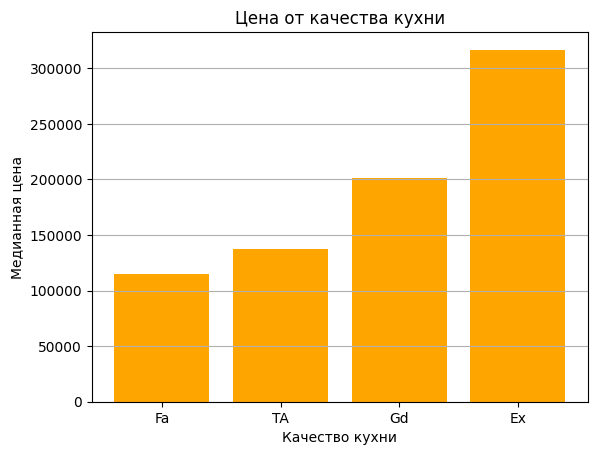

In [124]:
qual_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
kitchen_medians = []
for q in qual_order:
    median_price = df[df['KitchenQual'] == q]['SalePrice'].median()
    kitchen_medians.append(median_price)
plt.figure()
plt.bar(qual_order, kitchen_medians, color='orange')
plt.title('Цена от качества кухни')
plt.xlabel('Качество кухни')
plt.ylabel('Медианная цена')
plt.grid(True, axis='y')
plt.show()

In [125]:
df_garage = df.dropna(subset=['GarageArea', 'GarageCars', 'GarageQual']).copy()

качество = {'Po':1, 'Fa':2, 'TA':3, 'Gd':4, 'Ex':5}
df_garage['номер_качества'] = df_garage['GarageQual'].map(качество)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_garage['GarageArea'],
    y=df_garage['SalePrice'],
    mode='markers',
    marker=dict(
        size=df_garage['GarageCars'] * 8,
        color=df_garage['номер_качества'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title='Качество гаража (1-5)')
    ),
    text=[f'Гараж {a} кв.фт, {c} маш., цена ${p:,.0f}'
          for a, c, p in zip(df_garage['GarageArea'], df_garage['GarageCars'], df_garage['SalePrice'])],
    hovertemplate='%{text}<extra></extra>'
))

fig.update_layout(
    title='Цена дома в сравнении площади гаража (размер пузыря = число машин, цвет = качество)',
    xaxis_title='Площадь гаража',
    yaxis_title='Цена дома',
)

fig.show()


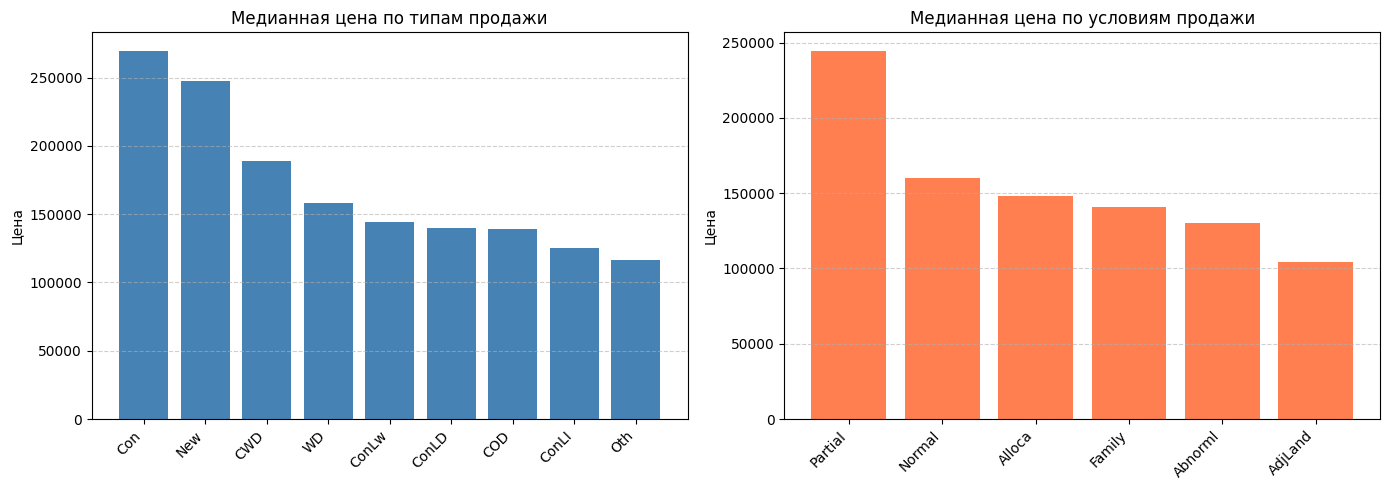

In [126]:
sale_type_stats = df.groupby('SaleType')['SalePrice'].agg(['median', 'mean', 'count']).sort_values('median', ascending=False)

sale_cond_stats = df.groupby('SaleCondition')['SalePrice'].agg(['median', 'mean', 'count']).sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sale_type_medians = sale_type_stats['median'].head(10)
axes[0].bar(range(len(sale_type_medians)), sale_type_medians.values, color='steelblue')
axes[0].set_xticks(range(len(sale_type_medians)))
axes[0].set_xticklabels(sale_type_medians.index, rotation=45, ha='right')
axes[0].set_title('Медианная цена по типам продажи')
axes[0].set_ylabel('Цена')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.6)

sale_cond_medians = sale_cond_stats['median']
axes[1].bar(range(len(sale_cond_medians)), sale_cond_medians.values, color='coral')
axes[1].set_xticks(range(len(sale_cond_medians)))
axes[1].set_xticklabels(sale_cond_medians.index, rotation=45, ha='right')
axes[1].set_title('Медианная цена по условиям продажи')
axes[1].set_ylabel('Цена')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

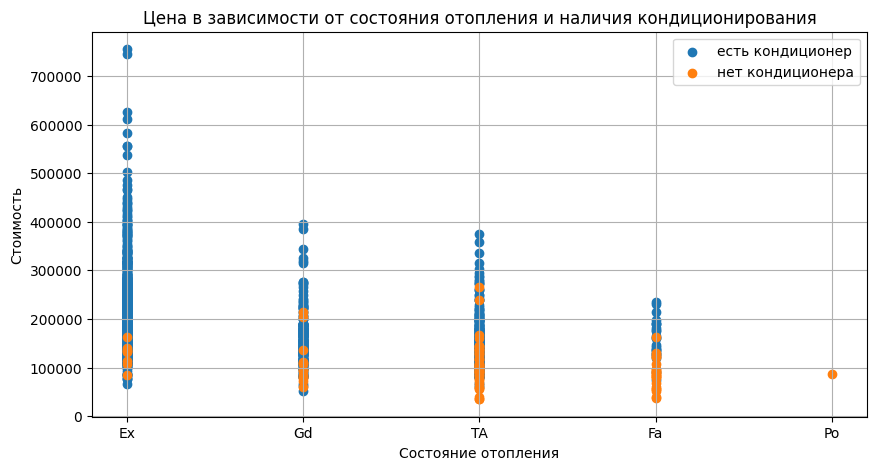

In [127]:
dfY = df[df.CentralAir == 'Y']
dfN = df[df.CentralAir == 'N']

plt.figure(figsize=(10, 5))

plt.scatter(dfY['HeatingQC'], dfY['SalePrice'], marker="o")
plt.scatter(dfN['HeatingQC'], dfN['SalePrice'], marker="o")

plt.title("Цена в зависимости от состояния отопления и наличия кондиционирования")
plt.xlabel("Состояние отопления")
plt.ylabel("Стоимость")
plt.grid(True)
plt.legend(["есть кондиционер", "нет кондиционера"])

plt.show()

In [128]:
print("""
Анализ влияния факторов на цену:

1. Жилая площадь: чем больше дом, тем дороже. При больших
   площадях разброс цен увеличивается.

2. Район: Самые дорогие районы:
   NoRidge, NridgHt, StoneBr. Самые дешёвые: MeadowV, IDOTRR. Разница в цене может достигать 3-4 раз.

3. Качество кухни: от Po (плохое) до Ex (отличное) медианная цена заметно растёт.

4. Гараж: дома с большим гаражом и с местом на много машин стоят дороже. Размер гаража
   связан с общей ценой.

5. Тип продажи: дома по контракту (Con) и новые дома (New) стоят дороже всего. Стандартные сделки (WD) — в середине.
   Oth, ConLI — самые дешёвые.

6. Условие продажи: частичная оплата или строительство (Partial) дают максимальную цену (обычно поскольку это новые дома).
   Аномальные условия (Abnorml, AdjLand) — минимальную.

7. Отопление и кондиционер: Дома с кондиционером почти всегда дороже, чем без него.
   Состояние отопления (HeatingQC) также влияет: лучше качество — выше цена.
   Даже при плохом отоплении (Po, Fa) дома с кондиционером могут стоить дороже, чем дома без кондиционера с хорошим отоплением.
   Это говорит о высоком приоритете кондиционера для покупателей.

Главные факторы по убыванию:
1. Район
2. Тип продажи дома
3. Жилая площадь
4. Характеристики гаража
5. Состояние кухни
6. Наличие кондиционера и качество отопления
7. Условия продажи

""")


Анализ влияния факторов на цену:

1. Жилая площадь: чем больше дом, тем дороже. При больших
   площадях разброс цен увеличивается.

2. Район: Самые дорогие районы:
   NoRidge, NridgHt, StoneBr. Самые дешёвые: MeadowV, IDOTRR. Разница в цене может достигать 3-4 раз.

3. Качество кухни: от Po (плохое) до Ex (отличное) медианная цена заметно растёт.

4. Гараж: дома с большим гаражом и с местом на много машин стоят дороже. Размер гаража
   связан с общей ценой.

5. Тип продажи: дома по контракту (Con) и новые дома (New) стоят дороже всего. Стандартные сделки (WD) — в середине.
   Oth, ConLI — самые дешёвые.

6. Условие продажи: частичная оплата или строительство (Partial) дают максимальную цену (обычно поскольку это новые дома).
   Аномальные условия (Abnorml, AdjLand) — минимальную.

7. Отопление и кондиционер: Дома с кондиционером почти всегда дороже, чем без него.
   Состояние отопления (HeatingQC) также влияет: лучше качество — выше цена.
   Даже при плохом отоплении (Po, Fa) дома с к